## Fase 4: Presidentes y directiva

Continuación de la reflexión documentada al cierre de Fase 2: si el entrenador se asocia con más variación en el rendimiento que el gasto o la cantera, ¿pasa lo mismo con la presidencia del club? Este notebook construye una tabla de presidentes del FC Barcelona por temporada (1993/94-2025/26) y analiza su relación con rendimiento, gasto y valor de plantilla, con la misma metodología ya usada para entrenadores.

**Limitación declarada desde el inicio:** esto no resuelve la pregunta de fondo planteada en la reflexión (si el patrón es específico del Barça o generalizable a otros clubes), porque eso requeriría datos de otros equipos, fuera del alcance de este proyecto. Lo que sí permite es ver si, dentro del propio Barça, la presidencia muestra el mismo tipo de variación que ya se observó con el entrenador.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr

df_maestro = pd.read_csv('../data/processed/df_maestro.csv', dtype={'temporada': str})

### Recolección de la tabla de presidentes

Fuente: Wikipedia y el sitio oficial del FC Barcelona, con fechas de mandato verificadas para los casos de cambio a mitad de temporada. Mismo diseño que `entrenadores_detalle.csv`: una tabla detallada por tramos, de la que se deriva una tabla agregada de un presidente "principal" por temporada.

In [4]:
presidentes_detalle = [
    {'temporada': '9394', 'presidente': 'Josep Lluís Núñez', 'tipo': 'principal', 'notas': ''},
    {'temporada': '9495', 'presidente': 'Josep Lluís Núñez', 'tipo': 'principal', 'notas': ''},
    {'temporada': '9596', 'presidente': 'Josep Lluís Núñez', 'tipo': 'principal', 'notas': ''},
    {'temporada': '9697', 'presidente': 'Josep Lluís Núñez', 'tipo': 'principal', 'notas': ''},
    {'temporada': '9798', 'presidente': 'Josep Lluís Núñez', 'tipo': 'principal', 'notas': ''},
    {'temporada': '9899', 'presidente': 'Josep Lluís Núñez', 'tipo': 'principal', 'notas': ''},
    {'temporada': '9900', 'presidente': 'Josep Lluís Núñez', 'tipo': 'principal', 'notas': 'Dimite 23/07/2000, al cierre de temporada'},
    {'temporada': '0001', 'presidente': 'Joan Gaspart', 'tipo': 'principal', 'notas': ''},
    {'temporada': '0102', 'presidente': 'Joan Gaspart', 'tipo': 'principal', 'notas': ''},
    {'temporada': '0203', 'presidente': 'Joan Gaspart', 'tipo': 'principal', 'notas': 'Dimite 12/02/2003'},
    {'temporada': '0203', 'presidente': 'Enric Reyna', 'tipo': 'interino', 'notas': '12/02/2003 al 06/05/2003'},
    {'temporada': '0203', 'presidente': 'Comisión Gestora', 'tipo': 'interino', 'notas': 'Desde 06/05/2003 hasta cierre de temporada'},
    {'temporada': '0304', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': 'Asume 15/06/2003, antes del inicio de esta temporada'},
    {'temporada': '0405', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': ''},
    {'temporada': '0506', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': ''},
    {'temporada': '0607', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': ''},
    {'temporada': '0708', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': ''},
    {'temporada': '0809', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': ''},
    {'temporada': '0910', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': 'Termina mandato 30/06/2010, al cierre de temporada'},
    {'temporada': '1011', 'presidente': 'Sandro Rosell', 'tipo': 'principal', 'notas': ''},
    {'temporada': '1112', 'presidente': 'Sandro Rosell', 'tipo': 'principal', 'notas': ''},
    {'temporada': '1213', 'presidente': 'Sandro Rosell', 'tipo': 'principal', 'notas': ''},
    {'temporada': '1314', 'presidente': 'Sandro Rosell', 'tipo': 'principal', 'notas': 'Dimite 23/01/2014 (caso Neymar)'},
    {'temporada': '1314', 'presidente': 'Josep Maria Bartomeu', 'tipo': 'principal', 'notas': 'Resto de temporada, era vicepresidente de Rosell'},
    {'temporada': '1415', 'presidente': 'Josep Maria Bartomeu', 'tipo': 'principal', 'notas': ''},
    {'temporada': '1516', 'presidente': 'Josep Maria Bartomeu', 'tipo': 'principal', 'notas': ''},
    {'temporada': '1617', 'presidente': 'Josep Maria Bartomeu', 'tipo': 'principal', 'notas': ''},
    {'temporada': '1718', 'presidente': 'Josep Maria Bartomeu', 'tipo': 'principal', 'notas': ''},
    {'temporada': '1819', 'presidente': 'Josep Maria Bartomeu', 'tipo': 'principal', 'notas': ''},
    {'temporada': '1920', 'presidente': 'Josep Maria Bartomeu', 'tipo': 'principal', 'notas': ''},
    {'temporada': '2021', 'presidente': 'Josep Maria Bartomeu', 'tipo': 'principal', 'notas': 'Dimite 27/10/2020'},
    {'temporada': '2021', 'presidente': 'Carles Tusquets', 'tipo': 'interino', 'notas': 'Comisión gestora, 27/10/2020 a marzo 2021'},
    {'temporada': '2021', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': 'Reelegido, asume ~marzo 2021, resto de temporada'},
    {'temporada': '2122', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': ''},
    {'temporada': '2223', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': ''},
    {'temporada': '2324', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': ''},
    {'temporada': '2425', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': ''},
    {'temporada': '2526', 'presidente': 'Joan Laporta', 'tipo': 'principal', 'notas': 'Temporada actual'},
]

presidentes_detalle = pd.DataFrame(presidentes_detalle)
presidentes_detalle.to_csv('../data/raw/presidentes_detalle.csv', index=False)
print(len(presidentes_detalle))
presidentes_detalle

38


,temporada,presidente,tipo,notas
0,9394,Josep Lluís Núñez,principal,
1,9495,Josep Lluís Núñez,principal,
2,9596,Josep Lluís Núñez,principal,
3,9697,Josep Lluís Núñez,principal,
4,9798,Josep Lluís Núñez,principal,
5,9899,Josep Lluís Núñez,principal,
6,9900,Josep Lluís Núñez,principal,"Dimite 23/07/2000, al cierre de temporada"
7,0001,Joan Gaspart,principal,
8,0102,Joan Gaspart,principal,
9,0203,Joan Gaspart,principal,Dimite 12/02/2003


In [5]:
presidentes_temporada = (
    presidentes_detalle[presidentes_detalle['tipo'] == 'principal']
    .groupby('temporada')
    .first()
    .reset_index()[['temporada', 'presidente']]
    .rename(columns={'presidente': 'presidente_principal'})
)

cambios = presidentes_detalle.groupby('temporada').size().reset_index(name='num_tramos')
presidentes_temporada = presidentes_temporada.merge(cambios, on='temporada')
presidentes_temporada['hubo_cambio_presidente'] = presidentes_temporada['num_tramos'] > 1
presidentes_temporada = presidentes_temporada.drop(columns='num_tramos')

presidentes_temporada.to_csv('../data/processed/presidentes_temporada.csv', index=False)
print(len(presidentes_temporada))
presidentes_temporada

33


,temporada,presidente_principal,hubo_cambio_presidente
0,0001,Joan Gaspart,False
1,0102,Joan Gaspart,False
2,0203,Joan Gaspart,True
3,0304,Joan Laporta,False
4,0405,Joan Laporta,False
5,0506,Joan Laporta,False
6,0607,Joan Laporta,False
7,0708,Joan Laporta,False
8,0809,Joan Laporta,False
9,0910,Joan Laporta,False


### Unión con el dataset maestro

Se cruza `presidentes_temporada` con `df_maestro` por temporada, para poder analizar rendimiento, gasto y valor de plantilla por presidente con la misma metodología ya usada para entrenadores.

In [6]:
df_maestro = df_maestro.merge(presidentes_temporada, on='temporada', how='left')
df_maestro.to_csv('../data/processed/df_maestro.csv', index=False)
df_maestro[['temporada', 'presidente_principal', 'hubo_cambio_presidente']].head(10)

,temporada,presidente_principal,hubo_cambio_presidente
0,9394,Josep Lluís Núñez,False
1,9495,Josep Lluís Núñez,False
2,9596,Josep Lluís Núñez,False
3,9697,Josep Lluís Núñez,False
4,9798,Josep Lluís Núñez,False
5,9899,Josep Lluís Núñez,False
6,9900,Josep Lluís Núñez,False
7,0001,Joan Gaspart,False
8,0102,Joan Gaspart,False
9,0203,Joan Gaspart,True


### Rendimiento por presidente

Mismo criterio de muestra mínima ya aplicado con entrenadores: se separan presidentes con 2+ temporadas de los que tienen 1 sola, tratados como casos aislados no comparables.

In [7]:
resumen_presidentes = df_maestro.groupby('presidente_principal').agg(
    temporadas=('temporada', 'count'),
    rendimiento_promedio=('rendimiento_relativo', 'mean'),
    titulos=('categoria_temporada', lambda x: (x == 'Título').sum())
).reset_index().sort_values('rendimiento_promedio', ascending=False)

resumen_presidentes

,presidente_principal,temporadas,rendimiento_promedio,titulos
4,Sandro Rosell,4,0.820175,2
3,Josep Maria Bartomeu,7,0.771930,4
1,Joan Laporta,12,0.727339,7
2,Josep Lluís Núñez,7,0.656403,3
0,Joan Gaspart,3,0.535088,0


In [8]:
presidentes_confiables = resumen_presidentes[resumen_presidentes['temporadas'] >= 2]
presidentes_una_temporada = resumen_presidentes[resumen_presidentes['temporadas'] < 2]

print('Presidentes con 2+ temporadas:')
print(presidentes_confiables)
print()
print('Presidentes con 1 sola temporada (caso aislado):')
print(presidentes_una_temporada)

Presidentes con 2+ temporadas:
   presidente_principal  temporadas  rendimiento_promedio  titulos
4         Sandro Rosell           4              0.820175        2
3  Josep Maria Bartomeu           7              0.771930        4
1          Joan Laporta          12              0.727339        7
2     Josep Lluís Núñez           7              0.656403        3
0          Joan Gaspart           3              0.535088        0

Presidentes con 1 sola temporada (caso aislado):
Empty DataFrame
Columns: [presidente_principal, temporadas, rendimiento_promedio, titulos]
Index: []


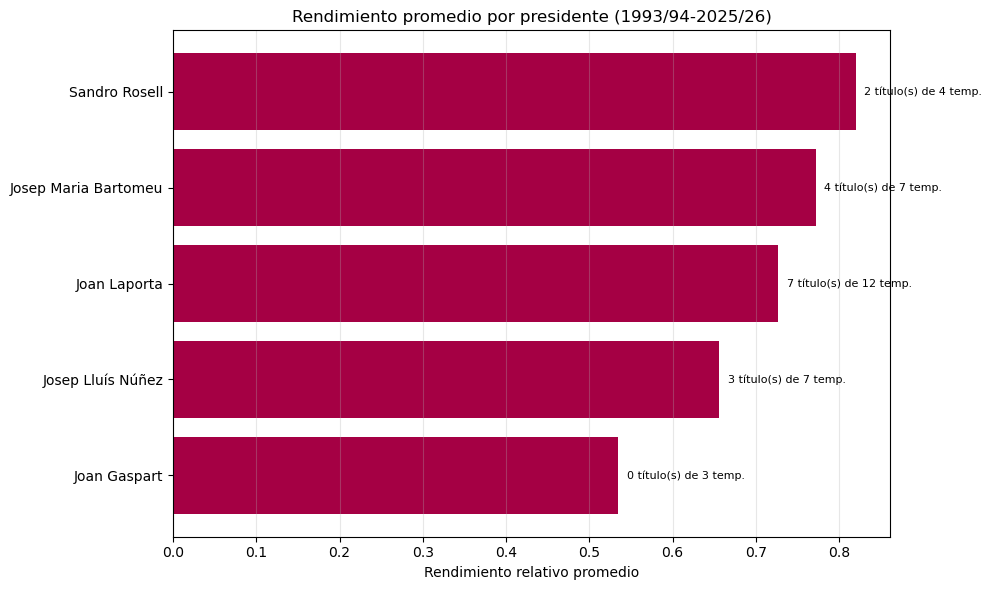

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
resumen_ordenado = resumen_presidentes.sort_values('rendimiento_promedio')

ax.barh(resumen_ordenado['presidente_principal'], resumen_ordenado['rendimiento_promedio'], color='#a50044')

for i, (rendimiento, temporadas, titulos) in enumerate(zip(
    resumen_ordenado['rendimiento_promedio'], resumen_ordenado['temporadas'], resumen_ordenado['titulos']
)):
    ax.text(rendimiento + 0.01, i, f'{titulos} título(s) de {temporadas} temp.', va='center', fontsize=8)

ax.set_xlabel('Rendimiento relativo promedio')
ax.set_title('Rendimiento promedio por presidente (1993/94-2025/26)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig('../reports/figures/rendimiento_por_presidente.png', dpi=150, bbox_inches='tight')
plt.show()

### Gasto y valor de plantilla por presidente

Mismo análisis que ya se hizo con entrenadores: comparar gasto relativo al mercado y valor de plantilla generado, por presidente, para ver si el patrón de "el factor humano pesa más que el gasto" se sostiene también a este nivel de decisión.

In [10]:
resumen_presidentes_completo = df_maestro.groupby('presidente_principal').agg(
    temporadas=('temporada', 'count'),
    rendimiento_promedio=('rendimiento_relativo', 'mean'),
    titulos=('categoria_temporada', lambda x: (x == 'Título').sum()),
    gasto_promedio=('proporcion_mercado_barca', 'mean')
).reset_index().sort_values('rendimiento_promedio', ascending=False)

resumen_presidentes_completo

,presidente_principal,temporadas,rendimiento_promedio,titulos,gasto_promedio
4,Sandro Rosell,4,0.820175,2,0.112569
3,Josep Maria Bartomeu,7,0.771930,4,0.079319
1,Joan Laporta,12,0.727339,7,0.074800
2,Josep Lluís Núñez,7,0.656403,3,0.052237
0,Joan Gaspart,3,0.535088,0,0.074956


In [11]:
valor_plantilla = pd.read_csv('../data/processed/valor_plantilla_temporada.csv', dtype={'temporada': str})

presidentes_valor = valor_plantilla.merge(presidentes_temporada, on='temporada')
resumen_valor_presidente = presidentes_valor.groupby('presidente_principal').agg(
    temporadas=('temporada', 'count'),
    valor_relativo_promedio=('valor_relativo_plantilla', 'mean')
).reset_index().sort_values('valor_relativo_promedio', ascending=False)

resumen_valor_presidente

,presidente_principal,temporadas,valor_relativo_promedio
2,Sandro Rosell,2,0.179745
1,Josep Maria Bartomeu,7,0.170506
0,Joan Laporta,5,0.165202


### Visualización: gasto y valor de plantilla por presidente

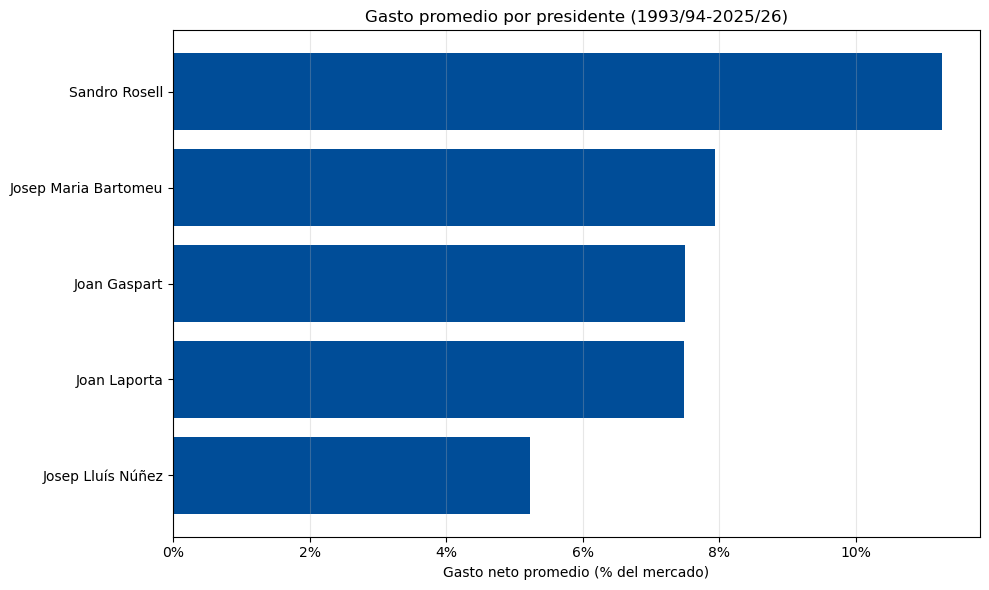

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
orden_gasto = resumen_presidentes_completo.sort_values('gasto_promedio')

ax.barh(orden_gasto['presidente_principal'], orden_gasto['gasto_promedio'], color='#004d98')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.set_xlabel('Gasto neto promedio (% del mercado)')
ax.set_title('Gasto promedio por presidente (1993/94-2025/26)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig('../reports/figures/gasto_por_presidente.png', dpi=150, bbox_inches='tight')
plt.show()

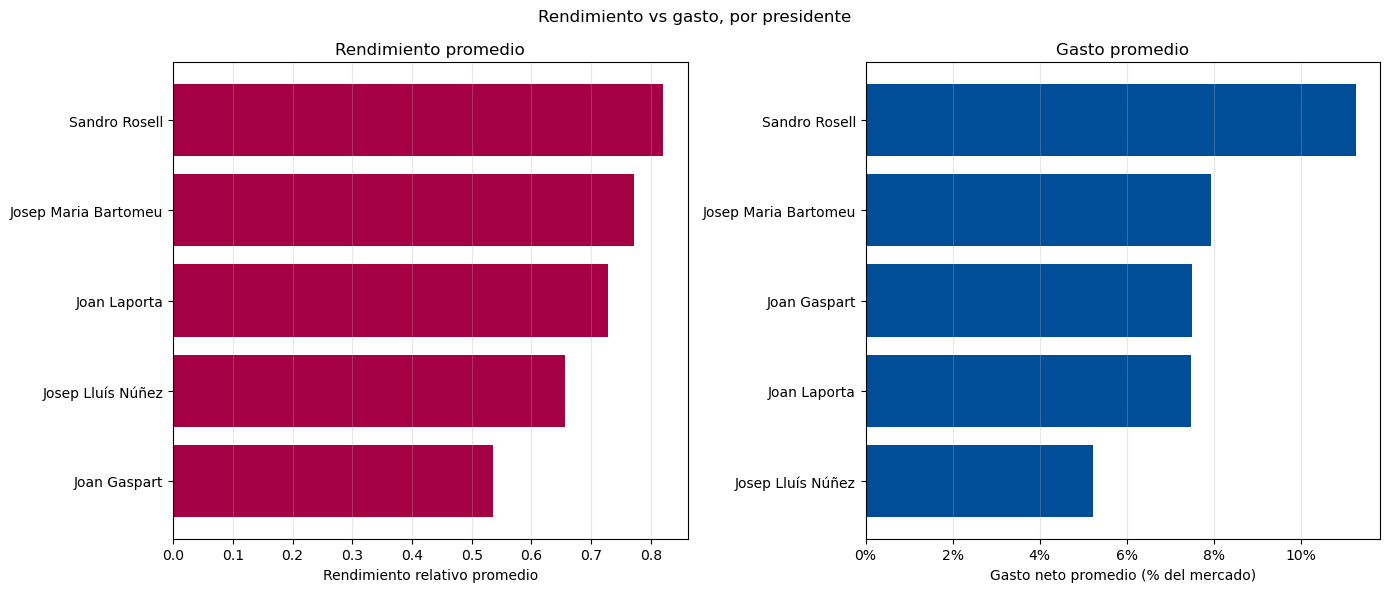

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden_rend = resumen_presidentes_completo.sort_values('rendimiento_promedio')
axes[0].barh(orden_rend['presidente_principal'], orden_rend['rendimiento_promedio'], color='#a50044')
axes[0].set_xlabel('Rendimiento relativo promedio')
axes[0].set_title('Rendimiento promedio')
axes[0].grid(True, alpha=0.3, axis='x')

orden_gasto = resumen_presidentes_completo.sort_values('gasto_promedio')
axes[1].barh(orden_gasto['presidente_principal'], orden_gasto['gasto_promedio'], color='#004d98')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
axes[1].set_xlabel('Gasto neto promedio (% del mercado)')
axes[1].set_title('Gasto promedio')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Rendimiento vs gasto, por presidente')
plt.tight_layout()
fig.savefig('../reports/figures/rendimiento_vs_gasto_presidente.png', dpi=150, bbox_inches='tight')
plt.show()

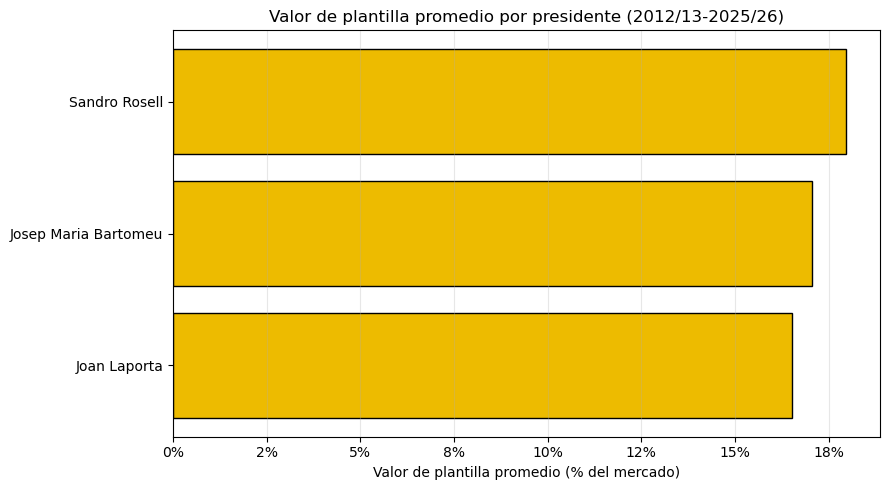

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
orden_valor = resumen_valor_presidente.sort_values('valor_relativo_promedio')

ax.barh(orden_valor['presidente_principal'], orden_valor['valor_relativo_promedio'], color='#edbb00', edgecolor='black')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.set_xlabel('Valor de plantilla promedio (% del mercado)')
ax.set_title('Valor de plantilla promedio por presidente (2012/13-2025/26)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig('../reports/figures/valor_plantilla_por_presidente.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusión de Fase 4: presidentes y directiva

**Corrección de lectura importante:** el gasto promedio por presidente no debe leerse como "más gasto es mejor gestión". Laporta llegó a la presidencia **ambas veces** en medio de crisis financieras heredadas de sus antecesores: en 2003, tras Joan Gaspart, quien había gastado 180 millones de euros en dos mercados (2000-2001) y dejó al club en tal estado que tuvo que regalar a Rivaldo al Milan solo para no pagar su sueldo. En 2021, tras Josep Maria Bartomeu, quien dejó una deuda de 1.350 millones de euros, tan grave que el club no pudo ni renovar a Messi, forzando su salida como agente libre.

**La evidencia visual confirma esto con claridad: Gaspart y Laporta tienen prácticamente el mismo gasto promedio (7.5% ambos), pero quedan en extremos opuestos de rendimiento** (Gaspart el peor de los cinco, Laporta el tercero, con la mayor cantidad absoluta de títulos del rango). Mismo nivel de gasto, resultado completamente distinto, señal directa de que el gasto promedio por sí solo no cuenta la historia completa: importa también el estado financiero y deportivo real que cada presidente encontró al asumir, algo que este dataset no mide directamente.

**Sobre rendimiento y valor de plantilla:** Sandro Rosell lidera las tres métricas (rendimiento 0.820, gasto 11.3%, valor de plantilla 18.0%), heredando y continuando la era Guardiola sobre una base ya sólida construida por el primer mandato de Laporta, no una crisis. Joan Gaspart tiene el peor rendimiento (0.535, 0 títulos) pese a un gasto similar al de Laporta, la crisis institucional más profunda del rango tanto en lo deportivo como en lo financiero.

**Limitación central de esta fase:** con datos de un solo club, no se puede aislar el efecto de las decisiones de la presidencia de otros factores compartidos por toda una era (herencia financiera del antecesor, calidad de cantera disponible, rivales de esa época). Sigue sin poder confirmarse ni descartarse la hipótesis planteada en la reflexión de Fase 2, pero el patrón de Laporta limpiando dos crisis heredadas con gasto similar al de quien generó esas crisis es un matiz real: el "factor humano" no se mide bien solo por el promedio de gasto, también importa la situación que cada presidente encontró al llegar.

**Con esto se cierra la Fase 4 del proyecto.**